# Ce notebook servira à explorer le jeu de données brute
## Les données brutes se situeront dans ...\racine du repo\data\raw

In [1]:
from accidents.data import fetch_collisions, load_collisions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

## Telecharge le CSV si pas deja present dans data/raw/

In [2]:
# force=True pour forcer le re-telechargement
path = fetch_collisions(raw_dir='data/raw', force=False)

Fichier deja present : C:\Users\Pierre Emery\Documents\Projets\bixi\data\raw\collisions_routieres.csv


In [3]:
df = load_collisions(path)
print(f'Shape : {df.shape}')

Charge : 218,272 lignes x 68 colonnes  (collisions_routieres.csv)
Shape : (218272, 68)


In [4]:
df.head()

,NO_SEQ_COLL,JR_SEMN_ACCDN,DT_ACCDN,CD_MUNCP,NO_CIVIQ_ACCDN,SFX_NO_CIVIQ_ACCDN,BORNE_KM_ACCDN,RUE_ACCDN,TP_REPRR_ACCDN,ACCDN_PRES_DE,...,NB_VICTIMES_VELO,VITESSE_AUTOR,LOC_X,LOC_Y,LOC_COTE_QD,LOC_COTE_PD,LOC_DETACHEE,LOC_IMPRECISION,LOC_LONG,LOC_LAT
0,SPVM _ 2012 _ 1,ME,2012/02/01,66102.0,3501.0,NaN,NaN,ST CHARLES,2.0,STAT,...,0,NaN,276517.37950,5.035127e+06,A,3,O,N,-73.861616,45.455505
1,SPVM _ 2012 _ 10,MA,2012/01/03,66023.0,NaN,NaN,NaN,TERR VILLE DE MTL,NaN,NaN,...,0,NaN,275209.46185,5.038619e+06,B,4,N,N,-73.878549,45.486871
2,SPVM _ 2012 _ 100,VE,2012/02/24,66023.0,NaN,NaN,NaN,JACQUES BIZARD,1.0,CHERRIER,...,0,50.0,275759.07900,5.039027e+06,A,1,N,O,-73.871542,45.490564
3,SPVM _ 2012 _ 1000,JE,2012/10/11,66142.0,11800.0,NaN,NaN,BD SALABERRY,NaN,NaN,...,0,NaN,280970.09315,5.038348e+06,A,1,O,N,-73.804841,45.484648
4,SPVM _ 2012 _ 10000,DI,2012/04/22,66023.0,38.0,NaN,NaN,PL DU COMMERCE,NaN,NaN,...,0,NaN,301391.47638,5.036357e+06,A,1,O,N,-73.543590,45.467136


In [5]:
df.tail()

,NO_SEQ_COLL,JR_SEMN_ACCDN,DT_ACCDN,CD_MUNCP,NO_CIVIQ_ACCDN,SFX_NO_CIVIQ_ACCDN,BORNE_KM_ACCDN,RUE_ACCDN,TP_REPRR_ACCDN,ACCDN_PRES_DE,...,NB_VICTIMES_VELO,VITESSE_AUTOR,LOC_X,LOC_Y,LOC_COTE_QD,LOC_COTE_PD,LOC_DETACHEE,LOC_IMPRECISION,LOC_LONG,LOC_LAT
218267,SPVM _ 2021 _ 9995,ME,2021/07/28,66023.0,NaN,NaN,NaN,PARC DU AVEN,1.0,BERUBE RUE,...,0,40.0,297702.11400,5.041951e+06,A,1,N,N,-73.590852,45.517438
218268,SPVM _ 2021 _ 9996,ME,2021/07/28,66023.0,NaN,NaN,NaN,COTE-SAINTE-CATHERINE DE LA CHEM,1.0,MONT-ROYAL DU O AVEN,...,0,50.0,297747.89500,5.041766e+06,A,2,N,N,-73.590263,45.515779
218269,SPVM _ 2021 _ 9997,LU,2021/07/26,66023.0,5507.0,NaN,NaN,SAINT-ANDRE RUE,NaN,NaN,...,0,30.0,297554.60015,5.043556e+06,A,1,N,N,-73.592764,45.531882
218270,SPVM _ 2021 _ 9998,ME,2021/07/28,66023.0,NaN,NaN,NaN,CHAMBORD RUE,1.0,MONT-ROYAL DU E AVEN,...,1,30.0,298745.43500,5.043323e+06,A,1,N,N,-73.577514,45.529801
218271,SPVM _ 2021 _ 9999,ME,2021/07/28,66023.0,4158.0,NaN,NaN,HENRI-JULIEN AVEN,NaN,NaN,...,0,30.0,298645.45450,5.042302e+06,A,1,N,N,-73.578781,45.520607


In [6]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 218272 entries, 0 to 218271
Data columns (total 68 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   NO_SEQ_COLL                  218272 non-null  str    
 1   JR_SEMN_ACCDN                218272 non-null  str    
 2   DT_ACCDN                     218272 non-null  str    
 3   CD_MUNCP                     218265 non-null  float64
 4   NO_CIVIQ_ACCDN               93491 non-null   float64
 5   SFX_NO_CIVIQ_ACCDN           444 non-null     str    
 6   BORNE_KM_ACCDN               111 non-null     float64
 7   RUE_ACCDN                    205974 non-null  str    
 8   TP_REPRR_ACCDN               135965 non-null  float64
 9   ACCDN_PRES_DE                147189 non-null  str    
 10  NB_METRE_DIST_ACCD           60692 non-null   float64
 11  CD_GENRE_ACCDN               208205 non-null  float64
 12  CD_SIT_PRTCE_ACCDN           5195 non-null    float64
 13  CD_ETAT_SU

#### On voit bien quelques petites limitations, beaucoup de NaN, aussi le jeu de donnée s'arrête en 2021 (il est mentioné dans la description sur la page de la ville que si l'on veut les données plus récente il faut les chercher ici https://www.donneesquebec.ca/recherche/fr/dataset/rapports-d-accident mais ça s'arrête aussi en 2022)

In [7]:
missing = (
    pd.DataFrame({
        'n_manquant': df.isnull().sum(),
        'pct_manquant': (df.isnull().mean() * 100).round(2)
    })
    .sort_values('pct_manquant', ascending=False)
)

print(f'{(missing["n_manquant"] > 0).sum()} colonnes avec des valeurs manquantes sur {df.shape[1]}')
missing[missing['n_manquant'] > 0]

32 colonnes avec des valeurs manquantes sur 68


,n_manquant,pct_manquant
BORNE_KM_ACCDN,218161,99.95
CD_PNT_CDRNL_ROUTE,217882,99.82
SFX_NO_CIVIQ_ACCDN,217828,99.80
NO_ROUTE,217550,99.67
CD_ZON_TRAVX_ROUTR,213368,97.75
CD_SIT_PRTCE_ACCDN,213077,97.62
CD_POSI_ACCDN,169056,77.45
CD_ETAT_CHASS,165001,75.59
NB_METRE_DIST_ACCD,157580,72.19
CD_PNT_CDRNL_REPRR,150120,68.78


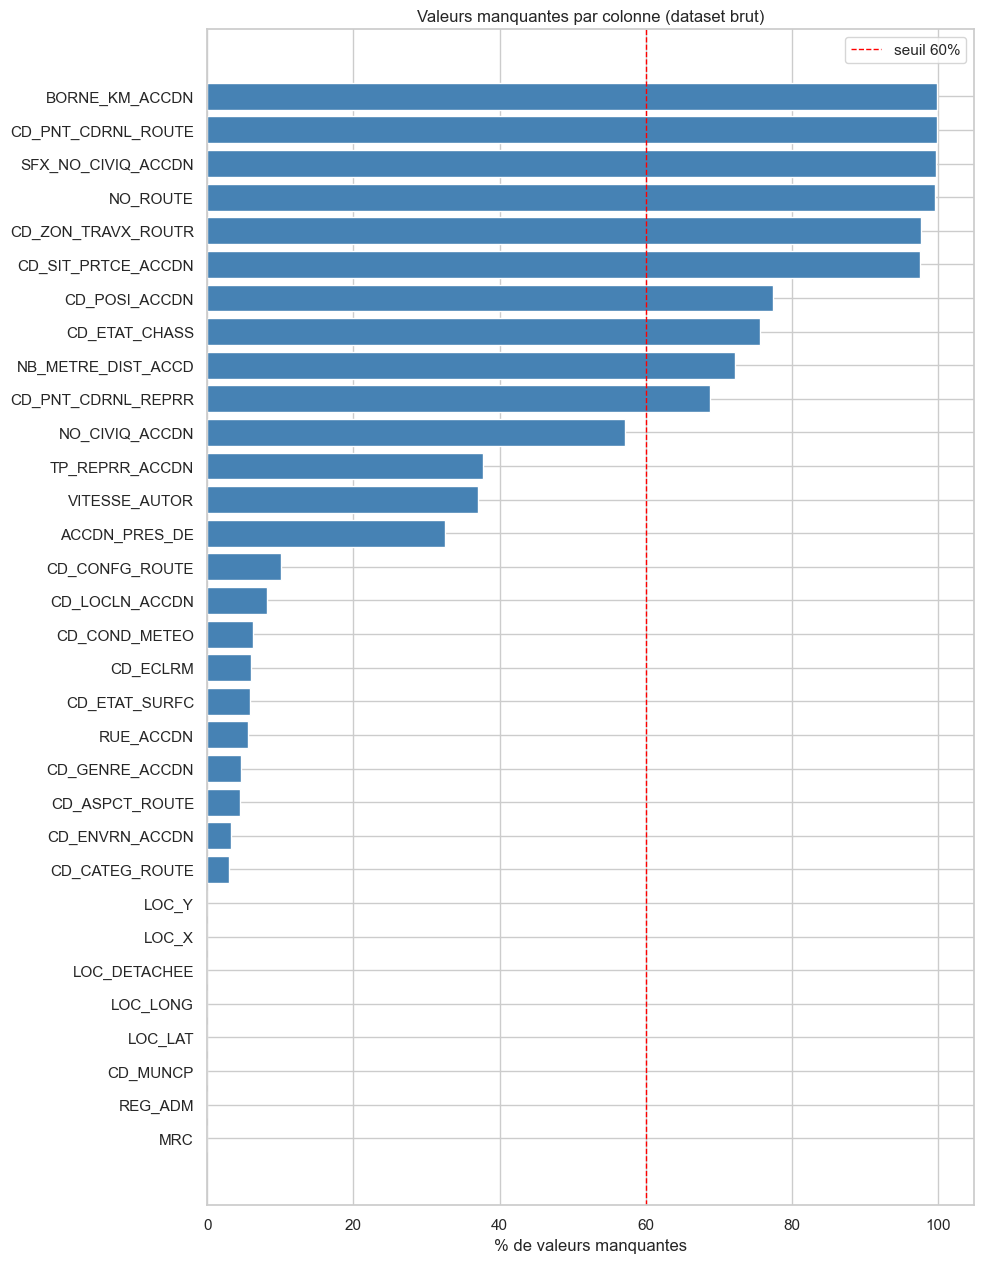

In [8]:
cols_with_missing = missing[missing['n_manquant'] > 0]

fig, ax = plt.subplots(figsize=(10, max(3, len(cols_with_missing) * 0.4)))
ax.barh(cols_with_missing.index, cols_with_missing['pct_manquant'], color='steelblue')
ax.axvline(60, color='red', linestyle='--', linewidth=1, label='seuil 60%') # j'ai mis un seuil pour l'instant mais j'ai pas encore établi de stratégie pour le nettoyage, reste à changer
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne (dataset brut)')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
summary = pd.DataFrame({
    'dtype':    df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'pct_nan':  (df.isnull().mean() * 100).round(2),
    'exemples': [str(df[c].dropna().unique()[:4].tolist()) for c in df.columns]
})
summary

,dtype,n_unique,pct_nan,exemples
NO_SEQ_COLL,str,218272,0.00,"['SPVM _ 2012 _ 1', 'SPVM _ 2012 _ 10', 'SPVM ..."
JR_SEMN_ACCDN,str,7,0.00,"['ME', 'MA', 'VE', 'JE']"
DT_ACCDN,str,3653,0.00,"['2012/02/01', '2012/01/03', '2012/02/24', '20..."
CD_MUNCP,float64,86,0.00,"[66102.0, 66023.0, 66142.0, 67025.0]"
NO_CIVIQ_ACCDN,float64,11753,57.17,"[3501.0, 11800.0, 38.0, 3735.0]"
...,...,...,...,...
LOC_COTE_PD,int64,4,0.00,"[3, 4, 1, 2]"
LOC_DETACHEE,str,2,0.01,"['O', 'N']"
LOC_IMPRECISION,str,2,0.00,"['N', 'O']"
LOC_LONG,float64,50159,0.01,"[-73.861616, -73.878549, -73.871542, -73.804841]"


## Vu qu'on compte étudier la gravité des accidents analysons un peu sa colonne

In [10]:
COL_GRAVITE = 'GRAVITE'

counts = df[COL_GRAVITE].value_counts(dropna=False).sort_index()
pct    = (counts / len(df) * 100).round(2)

pd.DataFrame({'n': counts, '%': pct})

,n,%
GRAVITE,,
Dommages matériels inférieurs au seuil de rapportage,87072,39.89
Dommages matériels seulement,83226,38.13
Grave,1786,0.82
Léger,45925,21.04
Mortel,263,0.12


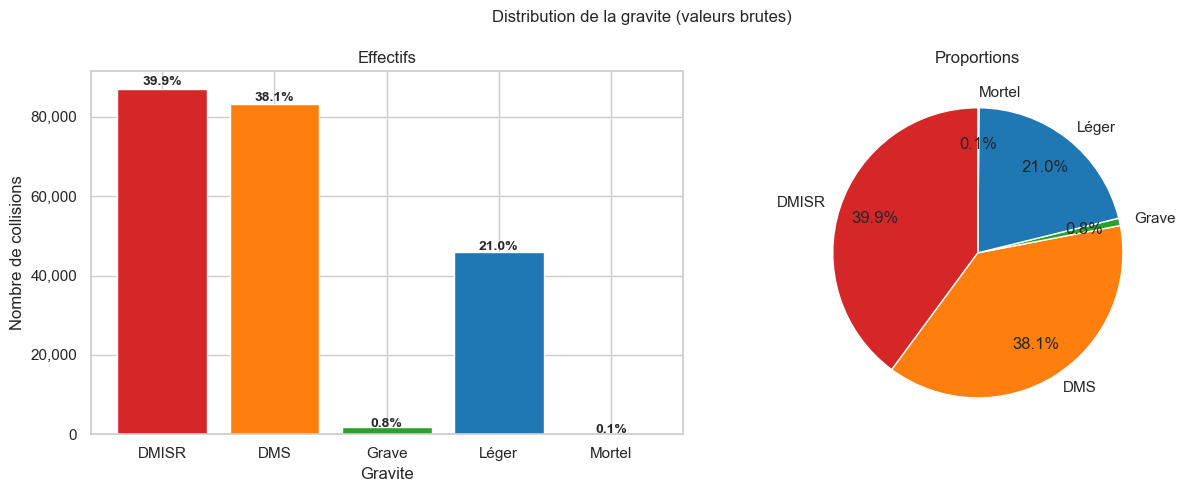

In [17]:
GRAVITE_LABELS = { # pour rendre les graphiques lisibles, sinon texte bcp trop long
    'Mortel':                        'Mortel',
    'Blessures graves':              'Bl. graves',
    'Blessures légères':             'Bl. legeres',
    'Dommages matériels seulement':  'DMS',
    'Dommages matériels inférieurs au seuil de rapportage':  'DMISR',
}

labels_courts = counts.index.map(lambda x: GRAVITE_LABELS.get(x, x))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution de la gravite (valeurs brutes)', fontsize=12)

colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

# Barplot
axes[0].bar(labels_courts, counts.values, color=colors[:len(counts)])
axes[0].set_title('Effectifs')
axes[0].set_xlabel('Gravite')
axes[0].set_ylabel('Nombre de collisions')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v * 1.01, f'{p:.1f}%', ha='center', fontsize=10, fontweight='bold')

# pie chart
axes[1].pie(
    counts.values,
    labels=labels_courts,
    autopct='%1.1f%%',
    colors=colors[:len(counts)],
    startangle=90,
    pctdistance=0.75,
)
axes[1].set_title('Proportions')

plt.tight_layout()
plt.show()

In [12]:
COL_DATE  = 'DT_ACCDN'
COL_HEURE = 'HEURE_ACCDN'

print('Exemples de valeurs brutes :')
print('Date  :', df[COL_DATE].dropna().unique()[:6])
print('Heure :', df[COL_HEURE].dropna().unique()[:6])

Exemples de valeurs brutes :
Date  : <StringArray>
['2012/02/01', '2012/01/03', '2012/02/24', '2012/10/11', '2012/04/22',
 '2012/04/25']
Length: 6, dtype: str
Heure : <StringArray>
[      'Non précisé', '02:00:00-02:59:00', '15:00:00-15:59:00',
 '21:00:00-21:59:00', '00:00:00-00:59:00', '07:00:00-07:59:00']
Length: 6, dtype: str


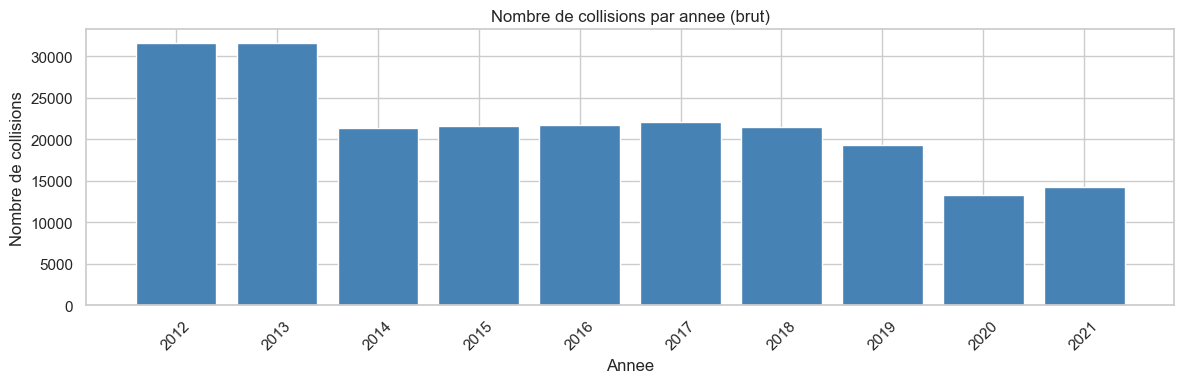

In [13]:
annees = df[COL_DATE].astype(str).str[:4]
annees_counts = annees.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(annees_counts.index, annees_counts.values, color='steelblue')
ax.set_title('Nombre de collisions par annee (brut)')
ax.set_xlabel('Annee')
ax.set_ylabel('Nombre de collisions')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Variables categorielles contextuelles a explorer, on les mets simplement manuellement ici
CAT_COLS = [
    'JR_SEMN_ACCDN',      # jour de la semaine
    'CD_GENRE_ACCDN',     # genre de collision
    'CD_ETAT_SURFC',      # etat de la surface
    'CD_ECLRM',           # eclairage
    'CD_ENVRN_ACCDN',     # environnement (urbain/rural)
    'CD_CATEG_ROUTE',     # categorie de route
    'CD_ASPCT_ROUTE',     # aspect de la route
    'CD_LOCLN_ACCDN',     # localisation longitudinale
    'CD_CONFG_ROUTE',     # configuration de la route
    'CD_COND_METEO',      # conditions meteorologiques
    'TP_REPRR_ACCDN',     # type de repere
    'GRAVITE',            # variable cible
    'REG_ADM',            # region administrative
]

In [22]:
for col in CAT_COLS:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False).to_string())


--- JR_SEMN_ACCDN ---
JR_SEMN_ACCDN
VE    35349
JE    35049
ME    33157
MA    32727
LU    30246
SA    28083
DI    23661

--- CD_GENRE_ACCDN ---
CD_GENRE_ACCDN
31.0    165734
32.0     11946
NaN      10067
33.0      7965
59.0      3330
99.0      2651
49.0      2528
40.0      2200
42.0      2069
52.0      1708
50.0      1528
41.0      1135
43.0      1107
38.0       909
39.0       532
75.0       335
72.0       321
48.0       313
47.0       301
44.0       261
51.0       254
35.0       202
45.0       199
37.0       143
71.0       114
53.0       114
74.0        93
46.0        74
54.0        44
34.0        31
73.0        29
55.0        29
36.0         6

--- CD_ETAT_SURFC ---
CD_ETAT_SURFC
11.0    135967
12.0     35195
16.0     21102
NaN      12760
18.0      6010
15.0      3203
17.0      2652
99.0       715
13.0       285
14.0       277
19.0        71
20.0        35

--- CD_ECLRM ---
CD_ECLRM
1.0    138142
3.0     55153
NaN     12919
2.0     10851
4.0      1207

--- CD_ENVRN_ACCDN ---
CD_ENVR

In [27]:
# quelques statistiques vite fait pour nos variables numériques
num_df = df.select_dtypes(include=[np.number])
print(f'{num_df.shape[1]} variables numeriques :')
num_df.describe().round(2)

53 variables numeriques :


,CD_MUNCP,NO_CIVIQ_ACCDN,BORNE_KM_ACCDN,TP_REPRR_ACCDN,NB_METRE_DIST_ACCD,CD_GENRE_ACCDN,CD_SIT_PRTCE_ACCDN,CD_ETAT_SURFC,CD_ECLRM,CD_ENVRN_ACCDN,...,NB_VICTIMES_MOTO,NB_DECES_VELO,NB_BLESSES_VELO,NB_VICTIMES_VELO,VITESSE_AUTOR,LOC_X,LOC_Y,LOC_COTE_PD,LOC_LONG,LOC_LAT
count,218265.00,93491.00,111.00,135965.00,60692.00,208205.00,5195.00,205512.00,205353.00,211217.00,...,218272.00,218272.00,218272.00,218272.00,137387.00,218261.00,218261.00,218272.00,218261.00,218261.00
mean,66023.16,4775.98,477.75,1.12,102.33,33.67,4.93,12.35,1.61,2.66,...,0.01,0.00,0.03,0.03,45.46,295222.92,5042984.98,1.21,-73.62,45.53
std,524.01,3823.67,1303.04,0.33,2058.06,9.40,3.55,5.48,0.90,0.94,...,0.09,0.01,0.17,0.17,8.72,6080.41,5971.79,0.59,0.08,0.05
min,1023.00,0.00,0.00,0.00,0.00,31.00,1.00,11.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,267986.99,5029289.36,1.00,-73.97,45.40
25%,66023.00,1498.00,4.30,1.00,5.00,31.00,1.00,11.00,1.00,2.00,...,0.00,0.00,0.00,0.00,40.00,293375.01,5038845.04,1.00,-73.65,45.49
50%,66023.00,4448.00,50.00,1.00,15.00,31.00,3.00,11.00,1.00,3.00,...,0.00,0.00,0.00,0.00,50.00,296435.48,5042725.58,1.00,-73.61,45.52
75%,66023.00,7141.00,142.50,1.00,50.00,31.00,9.00,12.00,3.00,3.00,...,0.00,0.00,0.00,0.00,50.00,299202.20,5046966.26,1.00,-73.57,45.56
max,94210.00,97850.00,8410.00,2.00,99999.00,99.00,9.00,99.00,4.00,9.00,...,3.00,1.00,2.00,2.00,100.00,306367.98,5062512.10,4.00,-73.48,45.70


In [28]:
COL_LAT = 'LOC_LAT'
COL_LON = 'LOC_LONG'

if COL_LAT in df.columns and COL_LON in df.columns:
    lat = pd.to_numeric(df[COL_LAT], errors='coerce')
    lon = pd.to_numeric(df[COL_LON], errors='coerce')

    print(f'Latitude  — min: {lat.min():.4f}  max: {lat.max():.4f}  NaN: {lat.isna().sum():,}')
    print(f'Longitude — min: {lon.min():.4f}  max: {lon.max():.4f}  NaN: {lon.isna().sum():,}')

    valides = lat.notna() & lon.notna()
    print(f'\nPoints avec coordonnees valides : {valides.sum():,} / {len(df):,} ({valides.mean()*100:.1f}%)')
else:
    print(f'Colonnes {COL_LAT} ou {COL_LON} introuvables — verifier les noms.')

Latitude  — min: 45.4027  max: 45.7025  NaN: 11
Longitude — min: -73.9705  max: -73.4799  NaN: 11

Points avec coordonnees valides : 218,261 / 218,272 (100.0%)


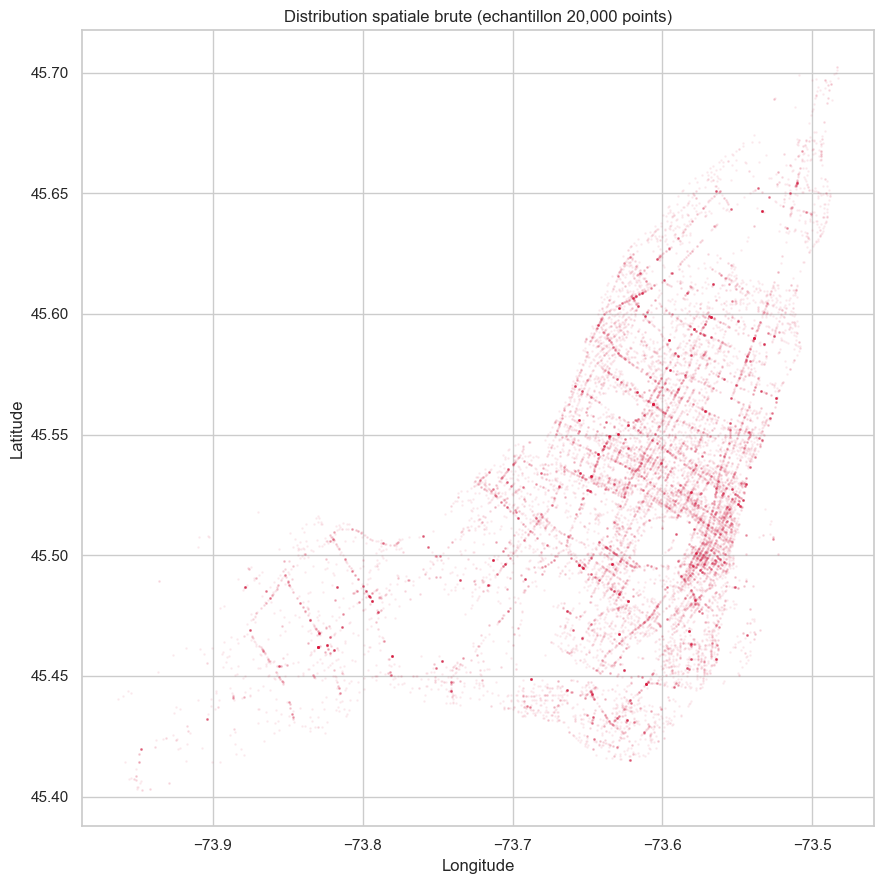

In [29]:
sample = df[valides].sample(min(20_000, valides.sum()), random_state=42)
lat_s = pd.to_numeric(sample[COL_LAT], errors='coerce')
lon_s = pd.to_numeric(sample[COL_LON], errors='coerce')

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(lon_s, lat_s, alpha=0.05, s=1, color='crimson')
ax.set_title(f'Distribution spatiale brute (echantillon {len(sample):,} points)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

# Conclusions
### Maintenant qu'on a fait une petite exploration du jeu de données brutes, on a une meilleure idée du nettoyage que nous devons faire.
### Pour faire bref, il faut traiter les nombreux NaN, encoder les variables catégorielles, standardiser.
### Le nettoyage se fera dans son propre notebook et on refera une exploration pour comparer les données avant/après nettoyage